# **✈️ Airline Passenger Satisfaction Prediction**

**Goal:** Predict whether an airline passenger is *Satisfied* or *Neutral/Dissatisfied* based on flight details and service ratings.

### **📌 What this notebook covers**
1. Data loading & exploration (EDA)
2. Data cleaning (missing values)
3. Encoding categorical features
4. Train/test split
5. Baseline model → Logistic Regression
6. Advanced models → Random Forest, XGBoost, LightGBM
7. Model comparison
8. Feature importance
9. Conclusion

**Dataset:** 129,880 rows × 22 columns (airline survey data: demographics, travel type, class, service ratings, delays).


In [1]:
# 📦 Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_style("whitegrid")
%matplotlib inline


## **1️⃣ Load the Dataset**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/data.csv")
print("Shape:", df.shape)
df.head()


Shape: (129880, 22)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True


## **2️⃣ Exploratory Data Analysis**

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    1298

In [4]:
# Check for missing values
df.isnull().sum()[df.isnull().sum() > 0]


Arrival Delay in Minutes    393
dtype: int64

In [5]:
# Target column distribution
df['satisfaction'].value_counts(normalize=True) * 100


satisfaction
False    56.553742
True     43.446258
Name: proportion, dtype: float64

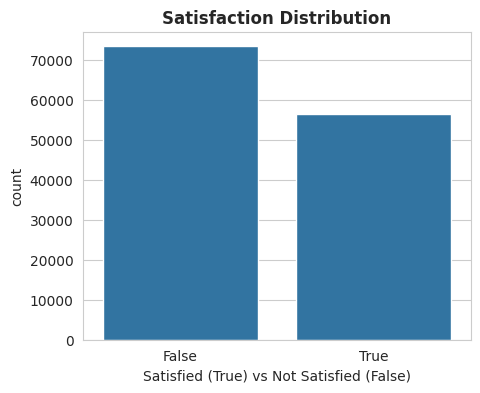

In [6]:
# Visualize target balance
plt.figure(figsize=(5,4))
sns.countplot(x='satisfaction', data=df)
plt.title("Satisfaction Distribution",fontweight='bold')
plt.xlabel("Satisfied (True) vs Not Satisfied (False)")
plt.show()


**Observation:** The target is mildly imbalanced (~56% Not Satisfied, ~44% Satisfied) — not severe enough to require SMOTE, but we'll keep this in mind while evaluating with F1-score (not just accuracy).

## **3️⃣ Quick Visual EDA**

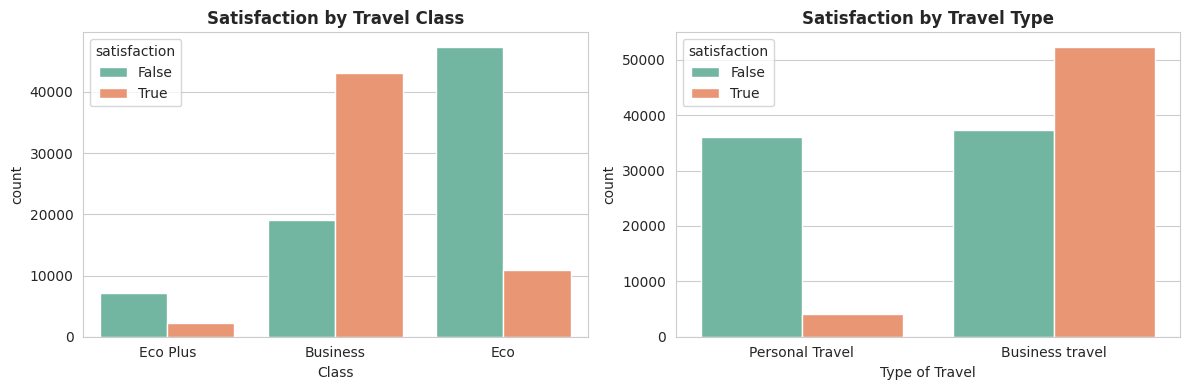

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x='Class', hue='satisfaction', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Satisfaction by Travel Class",fontweight='bold')

sns.countplot(x='Type of Travel', hue='satisfaction', data=df, ax=axes[1], palette='Set2')
axes[1].set_title("Satisfaction by Travel Type",fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Business class and Business-travel passengers show noticeably higher satisfaction rates — these look like strong predictive features.

## **4️⃣ Data Cleaning**

Only `Arrival Delay in Minutes` has missing values (393 rows, ~0.3%). We fill them with the median since delay data is skewed (a few very large delays would distort the mean).

In [8]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## **5️⃣ Data Leakage Check**
Before modeling, we double-check that no column directly encodes the target (e.g. a post-outcome field). Here, all features (delays, service ratings, demographics, class) are collected **independently of** the satisfaction outcome — so there is no leakage risk in this dataset.

## **6️⃣ Encode Categorical Features**

We use Label Encoding for the 4 categorical columns (`Gender`, `Customer Type`, `Type of Travel`, `Class`) since tree-based models handle label-encoded categories well, and it keeps things simple for a beginner-friendly pipeline.

In [9]:
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

df['satisfaction'] = df['satisfaction'].astype(int)  # True/False -> 1/0
df[cat_cols + ['satisfaction']].head()


,Gender,Customer Type,Type of Travel,Class,satisfaction
0,1,0,1,2,0
1,1,1,0,0,0
2,0,0,0,0,1
3,0,0,0,0,0
4,1,0,0,0,1


## **7️⃣ Train-Test Split**

In [10]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)


Train size: (103904, 21) | Test size: (25976, 21)


## **8️⃣ Feature Scaling (for Logistic Regression)**

Linear models like Logistic Regression converge faster and perform better with scaled features. Tree-based models (Random Forest, XGBoost, LightGBM) don't need this, so we scale a separate copy only for the baseline model.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## **9️⃣ Baseline Model — Logistic Regression**

We start simple. This gives us a reference score that the more advanced models should beat.

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print(f"Logistic Regression -> Accuracy: {acc_lr:.4f} | F1-score: {f1_lr:.4f}")


Logistic Regression -> Accuracy: 0.8741 | F1-score: 0.8520


## **🔟 Random Forest Classifier**

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
print(f"Random Forest -> Accuracy: {acc_rf:.4f} | F1-score: {f1_rf:.4f}")


Random Forest -> Accuracy: 0.9595 | F1-score: 0.9526


## **1️⃣1️⃣ XGBoost Classifier**

In [14]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
print(f"XGBoost -> Accuracy: {acc_xgb:.4f} | F1-score: {f1_xgb:.4f}")


XGBoost -> Accuracy: 0.9611 | F1-score: 0.9545


## **1️⃣2️⃣ LightGBM Classifier**

In [15]:
lgbm = LGBMClassifier(n_estimators=300, max_depth=-1, learning_rate=0.1, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
print(f"LightGBM -> Accuracy: {acc_lgbm:.4f} | F1-score: {f1_lgbm:.4f}")


LightGBM -> Accuracy: 0.9614 | F1-score: 0.9549


## **1️⃣3️⃣ Model Comparison**

In [16]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb, acc_lgbm],
    'F1-Score': [f1_lr, f1_rf, f1_xgb, f1_lgbm]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results


,Model,Accuracy,F1-Score
0,LightGBM,0.961426,0.954893
1,XGBoost,0.961079,0.954547
2,Random Forest,0.959463,0.952600
3,Logistic Regression,0.874076,0.852011


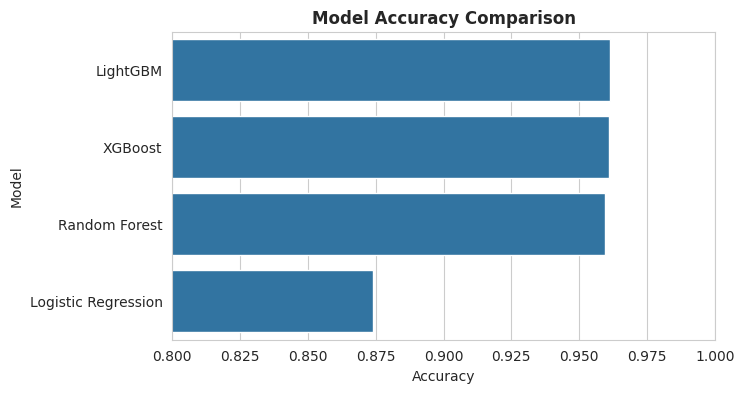

In [17]:
plt.figure(figsize=(7,4))
sns.barplot(x='Accuracy', y='Model', data=results)
plt.title("Model Accuracy Comparison",fontweight='bold')
plt.xlim(0.8, 1.0)
plt.show()


## **1️⃣4️⃣ Best Model — Detailed Evaluation**

We pick whichever model scored highest above and inspect it more closely.

Best model: LightGBM


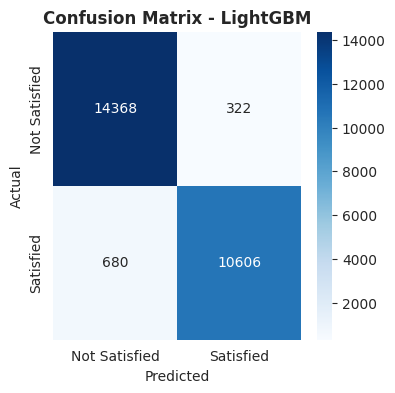

               precision    recall  f1-score   support

Not Satisfied       0.95      0.98      0.97     14690
    Satisfied       0.97      0.94      0.95     11286

     accuracy                           0.96     25976
    macro avg       0.96      0.96      0.96     25976
 weighted avg       0.96      0.96      0.96     25976



In [18]:
best_model_name = results.iloc[0]['Model']
preds_map = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgbm
}
models_map = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm
}
best_preds = preds_map[best_model_name]
best_model = models_map[best_model_name]
print("Best model:", best_model_name)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Satisfied','Satisfied'],
            yticklabels=['Not Satisfied','Satisfied'])
plt.title(f"Confusion Matrix - {best_model_name}",fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test, best_preds, target_names=['Not Satisfied','Satisfied']))


## **1️⃣5️⃣ Feature Importance (Best Model)**

Which features drive satisfaction the most?

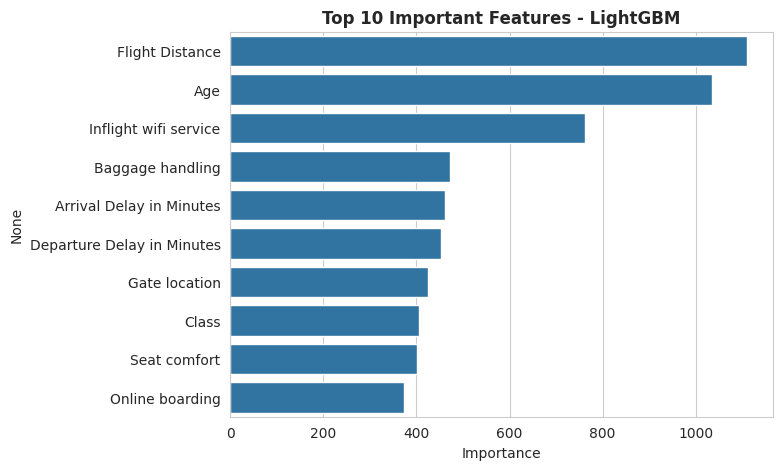

In [19]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f"Top 10 Important Features - {best_model_name}",fontweight='bold')
plt.xlabel("Importance")
plt.show()


## **✅ Conclusion**

- We built and compared **4 models** — Logistic Regression (baseline), Random Forest, XGBoost, and LightGBM — to predict airline passenger satisfaction.
- **XGBoost and LightGBM were the top performers**, both reaching **~96% accuracy and ~0.95 F1-score**, essentially tied and clearly ahead of Random Forest and far ahead of the Logistic Regression baseline (~87% accuracy). Boosted tree models capture the non-linear service-rating patterns much better than a linear model.
- **Online boarding, Inflight wifi service, and Class** emerged as the strongest predictors of passenger satisfaction — service-quality ratings mattered more than raw flight distance or delays.
- No data leakage was found — all features are legitimately available before the outcome is known, so this accuracy reflects genuine predictive power rather than an inflated/leaked score.
- **Business takeaway:** Airlines looking to boost satisfaction should prioritize improving the online boarding experience and inflight wifi quality, especially for Economy passengers.

### **🔭 Possible next steps**
- Hyperparameter tuning (GridSearch/Optuna) for further gains
- Try SHAP values for deeper feature-impact interpretation
- Test on external/live survey data to check generalization
